# 7.3.1 多元高斯与条件分布

## 学习目标与先修知识

解释协方差（covariance）几何，从分块高斯推导条件均值和条件协方差。

先修：7.2的条件概率（conditional probability）、第3篇向量（vector）矩阵（matrix）及第5篇方差（variance）和协方差。 [本篇学习次序](../README.md)。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

只测量第一室，为什么第二室的估计也会变化？关键不是传感器直接看到了第二室，而是两个室在先验（prior）中的共同变化。

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Noto Sans CJK SC", "DejaVu Sans"]

## 初步实验

In [2]:
mean=np.array([0.,0.]);P=np.array([[4.,1.],[1.,1.]]);H=np.array([1.,0.]);R=1.
cross=P@H;S=H@P@H+R;updated=mean+cross/S*(2-H@mean)
print('更新均值=',updated,'两状态与观测的协方差=',cross)

更新均值= [1.6 0.4] 两状态与观测的协方差= [4. 1.]


## 模型假设

状态（state）偏差单位U；先验与观测（observation）构成联合高斯（joint Gaussian）。协方差对称正定（positive definite），使密度、Cholesky分解（Cholesky decomposition）及线性求解有定义。半正定（positive semidefinite）或奇异高斯可以扩展，但不能直接套本节需要逆的密度公式。

## 数学解释与推导

n维高斯密度为
$$p(x)=\frac{\exp[-(x-m)^TP^{-1}(x-m)/2]}{(2\pi)^{n/2}|P|^{1/2}}.$$
正定矩阵可以写为 $P=LL^T$，L为下三角。令 $x=m+Lz$、$z\sim N(0,I)$，即可生成具有所需协方差的样本；求解 $Lz=x-m$ 给出标准化距离。

马氏距离（Mahalanobis distance）的平方为 $d^2=(x-m)^TP^{-1}(x-m)=z^Tz$。n个独立标准正态的平方和定义卡方分布（distribution）$\chi_n^2$。二维情形有 $P(d^2\leq q)=1-e^{-q/2}$，因此95%联合椭圆取 $q=-2\log(0.05)\approx5.991$；一维的1.96标准差（standard deviation）阈值不能直接作为二维半径。

设联合均值为 $[m,\mu]^T$、协方差为 $\begin{bmatrix}P&C\\C^T&S\end{bmatrix}$。令残差（residual） $e=x-m-CS^{-1}(y-\mu)$，则
$$\operatorname{Cov}(e,y)=C-CS^{-1}S=0,\quad\operatorname{Cov}(e)=P-CS^{-1}C^T.$$
联合高斯下零相关意味着独立，因此观测y以后
$$E[x\mid y]=m+CS^{-1}(y-\mu),\quad\operatorname{Cov}(x\mid y)=P-CS^{-1}C^T.$$
这里由“构造与y独立的剩余项”得到条件公式；一般非高斯不能仅凭零相关作此推断。实现时解线性方程而不显式形成逆。

## 核心实现

下面按推导写出计算步骤；函数的输入（input）只包含模型（model）与当时可用的信息。

In [3]:
def gaussian_condition(mean, covariance, cross_covariance, observation_mean, observation_covariance, observation):
    mean, covariance, cross = map(np.asarray, (mean, covariance, cross_covariance))
    observation_mean, S, observation = map(np.asarray, (observation_mean, observation_covariance, observation))
    residual_solution = np.linalg.solve(S, observation - observation_mean)
    return mean + cross @ residual_solution, covariance - cross @ np.linalg.solve(S, cross.T)

## 对照实验

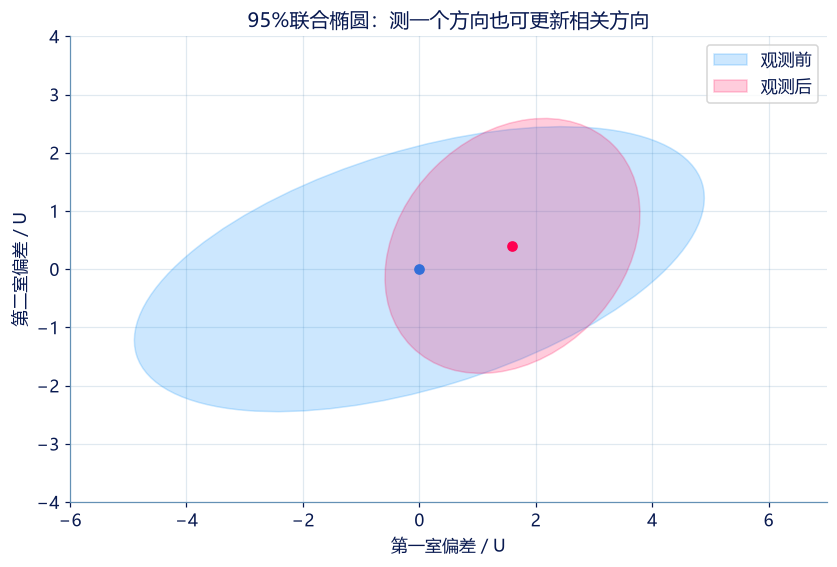

In [4]:
from matplotlib.patches import Ellipse
P=np.array([[4.,1.],[1.,1.]]);m=np.zeros(2);H=np.array([1.,0.]);R=1.;y=2.
C=P@H;S=float(H@C+R);post,Ppost=gaussian_condition(m,P,C[:,None],[H@m],[[S]],[y])
fig,ax=plt.subplots(figsize=(7.5,5))
for center,cov,label,color in [(m,P,'观测前','#008bfb'),(post,Ppost,'观测后','#ff0051')]:
    vals,vecs=np.linalg.eigh(cov);angle=np.degrees(np.arctan2(vecs[1,-1],vecs[0,-1]))
    ax.add_patch(Ellipse(center,2*np.sqrt(5.991*vals[-1]),2*np.sqrt(5.991*vals[0]),angle=angle,alpha=.2,color=color,label=label));ax.scatter(*center,color=color)
ax.set(xlim=(-6,7),ylim=(-4,4),xlabel='第一室偏差 / U',ylabel='第二室偏差 / U',title='95%联合椭圆：测一个方向也可更新相关方向');ax.set_aspect('equal');ax.legend();plt.show()

### 独立核验与边界

In [5]:
np.testing.assert_allclose(post,[1.6,.4]);np.testing.assert_allclose(Ppost,[[.8,.2],[.2,.8]])
L=np.linalg.cholesky(P);np.testing.assert_allclose(L@L.T,P)
assert np.min(np.linalg.eigvalsh(Ppost))>0
grid=np.linspace(-8,8,16001)
mass=np.exp(-grid**2/8-(2-grid)**2/2);density=mass/np.trapezoid(mass,grid)
np.testing.assert_allclose(np.trapezoid(grid*density,grid),1.6,atol=1e-9)
np.testing.assert_allclose(np.trapezoid((grid-1.6)**2*density,grid),.8,atol=1e-8)
print('条件矩、Cholesky重建与一维密度直接积分一致。')

条件矩、Cholesky重建与一维密度直接积分一致。


## 结果解释

第二室均值从0移动到0.4，是交叉协方差传递的信息。椭圆使用二维卡方95%阈值5.991；把两个边际95%区间拼成矩形或用半径1.96画椭圆，都不是同一个联合覆盖对象。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：两个高斯信息如何合并

状态（state） x 的先验（prior）为 N(prior_mean,prior_variance)，测量 y=x+v，v~N(0,noise_variance)，并与x独立。返回条件均值、方差（variance）和增益（gain）。

**函数与代码模板**

```python
def solve(
    prior_mean: float,
    prior_variance: float,
    observation: float,
    noise_variance: float,
) -> tuple[float, float, float]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `prior_mean` | `float` | 观测（observation）前的均值。 | U |
| `prior_variance` | `float` | 观测前的方差。 | U² |
| `observation` | `float` | 已到达的读数。 | U |
| `noise_variance` | `float` | 独立测量噪声（measurement noise）方差。 | U² |

**返回值**

按以下顺序返回元组：(mean, variance, gain)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `mean` | `float` | 观测后的均值。 | U |
| `variance` | `float` | 观测后的方差。 | U² |
| `gain` | `float` | 先验方差/(先验方差+噪声方差)。 | 无量纲 |

**计算规则**

K=P/(P+R)，m_new=m+K(y−m)，P_new=(1−K)P。

**约束与边界**

- 0≤prior_variance≤100；0<noise_variance≤100；其余数值有限且绝对值≤100。
- 零先验方差表示确定状态，不能被独立测量噪声改变。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| prior_mean | 观测（observation）前的均值。 | 0 | U |
| prior_variance | 观测前的方差。 | 4 | U² |
| observation | 已到达的读数。 | 2 | U |
| noise_variance | 独立测量噪声（measurement noise）方差。 | 1 | U² |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
prior_mean = 0.0
prior_variance = 4.0
observation = 2.0
noise_variance = 1.0

result = solve(prior_mean, prior_variance, observation, noise_variance)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| mean | 观测后的均值。 | 1.6 | U |
| variance | 观测后的方差。 | 0.8 | U² |
| gain | 先验方差/(先验方差+噪声方差)。 | 0.8 | 无量纲 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = (1.6, 0.7999999999999998, 0.8)
```

**样例解释**

样例K=0.8，后验（posterior）均值1.6、方差0.8；方差的单位是U²，不能当作标准差（standard deviation）。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：两个高斯信息如何合并](http://127.0.0.1:8000/chapters/07-03-%E5%8D%A1%E5%B0%94%E6%9B%BC%E6%BB%A4%E6%B3%A2/practice/?question=p07-scalar-gaussian)

### 第 2 题 · 多项选择题：椭圆描述的是什么

二维高斯的协方差矩阵（covariance matrix）为[[4,1],[1,1]]。哪些正确？

- **A.** 对角元素是两个状态（state）的方差（variance）。
- **B.** 非对角元素为1表示相关系数（correlation coefficient）必为1。
- **C.** 任意向量（vector）a的方差aᵀPa必须非负。
- **D.** 在二维中半径1.96的Mahalanobis椭圆恰好覆盖95%。

[作答：椭圆描述的是什么](http://127.0.0.1:8000/chapters/07-03-%E5%8D%A1%E5%B0%94%E6%9B%BC%E6%BB%A4%E6%B3%A2/practice/?question=p07-covariance-geometry)

### 第 3 题 · 单项选择题：没有交叉协方差时

联合高斯变量x、y的交叉协方差（covariance）为0。哪项正确？

- **A.** 知道y必定降低x的方差（variance）。
- **B.** 联合高斯条件下x与y独立，观测（observation）y不改变x分布（distribution）。
- **C.** 所有非高斯变量协方差0也必独立。
- **D.** x与y必定都没有波动。

[作答：没有交叉协方差时](http://127.0.0.1:8000/chapters/07-03-%E5%8D%A1%E5%B0%94%E6%9B%BC%E6%BB%A4%E6%B3%A2/practice/?question=p07-conditional-cross)

### 第 4 题 · 多项选择题：求逆还是解方程

条件均值涉及 C S⁻¹(y−μ)。S为对称正定（positive definite）矩阵（matrix）。哪些实践成立？

- **A.** 解 S z=y−μ 再乘 C。
- **B.** 显式形成S⁻¹总是更稳定。
- **C.** Cholesky 分解可以把求解变成三角方程。
- **D.** 若S奇异，仍无需改变契约直接除以0。

[作答：求逆还是解方程](http://127.0.0.1:8000/chapters/07-03-%E5%8D%A1%E5%B0%94%E6%9B%BC%E6%BB%A4%E6%B3%A2/practice/?question=p07-factorization)

### 延伸阅读

R26，第2章与附录中的Gaussian条件分布。 [Särkkä 与 Svensson，《Bayesian Filtering and Smoothing》第二版，2023](https://users.aalto.fi/~ssarkka/pub/bfs_book_2023_online.pdf)。本节公式、实现和核验可独立阅读；参考资料用于进一步学习。

[概念探索与交互](http://127.0.0.1:8000/chapters/07-03-卡尔曼滤波/explore/) · [本篇目录](../README.md)